In [9]:
# BLOQUE 1: CONFIGURACIÓN Y CARGA DE DATOS
# Importa las librerías necesarias y carga el dataset.

# 1. Importación de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Configuración visual para los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")

# 2. Carga del Dataset
# Se usa sep=';' debido a la estructura del archivo csv detectada
df = pd.read_csv('spotify_songs.csv', sep=';')

# Corrección de la primera columna indexada sin nombre
df.rename(columns={df.columns[0]: 'id_cancion'}, inplace=True)

# 3. Inspección Inicial en Consola
print(f"Dataset cargado con éxito. Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas.\n")
print("Columnas del dataset:")
print(df.columns.tolist())

# 4. Visualización de los datos cargados
df.head()

Dataset cargado con éxito. Dimensiones: 1000 filas x 23 columnas.

Columnas del dataset:
['id_cancion', 'artist_name', 'genres', 'followers', 'artist_popularity', 'artist_url', 'track_name', 'album_name', 'release_date', 'duration_ms', 'explicit', 'track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


,id_cancion,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,08/03/2024,228639,...,0.646,5,-8.334,1,0.0427,0.0615,3.04e-05,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,08/03/2024,173639,...,0.630,7,-5.854,0,0.0434,0.157,0.0,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,08/03/2024,92400,...,0.362,10,-9.480,1,0.0416,0.67,0.0,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),20/03/2020,191013,...,0.825,0,-4.645,1,0.0325,0.0215,2.44e-05,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,08/03/2024,214994,...,0.775,1,-6.614,1,0.0548,0.19,6.54e-05,0.1130,0.787,118.998


In [12]:
# BLOQUE 2: LIMPIEZA Y PREPARACIÓN
# Selección de características auditivas, manejo de nulos y escalamiento.

# 1. Definición de las columnas auditivas exactas solicitadas por el docente
audio_features = [
    'track_popularity', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

# 2. DEMOSTRACIÓN DE LIMPIEZA: Filtramos y eliminamos filas vacías
X_limpia = df[audio_features].dropna()

# Sincronizamos el dataset original por seguridad
df = df.loc[X_limpia.index].reset_index(drop=True)
X_limpia = X_limpia.reset_index(drop=True)

# 3. MOSTRAR LA TABLA LIMPIA (Solo con las columnas pedidas, sin artista ni género)
print("=== TABLA DE DATOS CON LA LIMPIEZA Y PREPARACIÓN APLICADA ===")
display(X_limpia.head())


# 4. PREPARACIÓN MATEMÁTICA: Escalamiento de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_limpia)

# 5. EXPLICACIÓN DEL DATO TOMADO COMO EJEMPLO (Primera canción del dataset)
print("\n=== DEMOSTRACIÓN DEL ESCALAMIENTO (EJEMPLO CON LA PRIMERA CANCIÓN) ===")
cancion_original = X_limpia.iloc[0]
cancion_escalada = X_scaled[0]

for col, orig, esc in zip(audio_features, cancion_original, cancion_escalada):
    print(f"Columna: {col:<18} | Valor Original: {orig:<6} -> Valor Escalado (Preparado): {esc:.4f}")

=== TABLA DE DATOS CON LA LIMPIEZA Y PREPARACIÓN APLICADA ===


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998



=== DEMOSTRACIÓN DEL ESCALAMIENTO (EJEMPLO CON LA PRIMERA CANCIÓN) ===
Columna: track_popularity   | Valor Original: 89.0   -> Valor Escalado (Preparado): 1.2387
Columna: danceability       | Valor Original: 0.645  -> Valor Escalado (Preparado): 0.2008
Columna: energy             | Valor Original: 0.646  -> Valor Escalado (Preparado): -0.0702
Columna: key                | Valor Original: 5.0    -> Valor Escalado (Preparado): -0.0673
Columna: loudness           | Valor Original: -8.334 -> Valor Escalado (Preparado): -0.2621
Columna: mode               | Valor Original: 1.0    -> Valor Escalado (Preparado): 0.7946
Columna: speechiness        | Valor Original: 0.0427 -> Valor Escalado (Preparado): -0.5388
Columna: acousticness       | Valor Original: 0.0615 -> Valor Escalado (Preparado): -0.7077
Columna: instrumentalness   | Valor Original: 3.04e-05 -> Valor Escalado (Preparado): -0.3313
Columna: liveness           | Valor Original: 0.074  -> Valor Escalado (Preparado): -0.7897
Columna: 

=== RESULTADO DE LA REDUCCIÓN DE DIMENSIONALIDAD (PCA) ===
Forma original de los datos escalados: (1000, 12)
Nueva forma de los datos reducidos con PCA: (1000, 2)

Varianza capturada por el Componente 1: 24.91%
Varianza capturada por el Componente 2: 12.77%
INFORMACIÓN TOTAL RETENIDA EN EL GRÁFICO 2D: 37.68%

=== VISTA PREVIA DE LAS NUEVAS COORDENADAS MATEMÁTICAS (2D) ===


,Componente_Principal_1,Componente_Principal_2
0,0.063185,0.129111
1,0.609885,1.542816
2,-1.725773,1.120047
3,1.178713,-0.074323
4,1.060287,0.941007


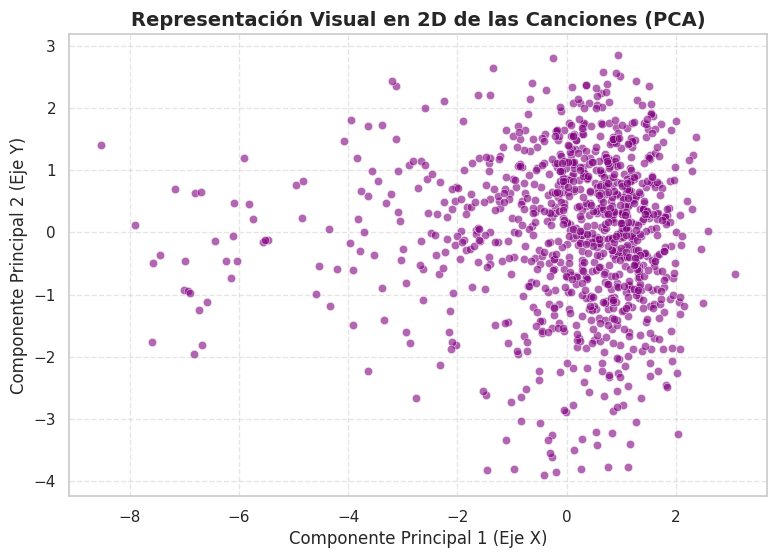

In [14]:
# BLOQUE 3: REDUCCIÓN DE DIMENSIONALIDAD (PCA)
# Reduce los datos a 2 componentes principales para poder visualizarlos en un gráfico 2D.

# 1. Configuración y aplicación de PCA fijando exactamente 2 componentes
pca_2d = PCA(n_components=2, random_state=42)

# Transformamos la matriz escalada (X_scaled del Bloque 2) a las nuevas 2 dimensiones
X_pca = pca_2d.fit_transform(X_scaled)

# 2. Creación de un nuevo DataFrame para almacenar el resultado tridimensional/gráfico
df_pca = pd.DataFrame(data=X_pca, columns=['Componente_Principal_1', 'Componente_Principal_2'])

# Calculamos el porcentaje de información retenida
varianza_explicada = pca_2d.explained_variance_ratio_
varianza_total_2d = sum(varianza_explicada) * 100

# 3. Demostración técnica del resultado en pantalla
print("=== RESULTADO DE LA REDUCCIÓN DE DIMENSIONALIDAD (PCA) ===")
print(f"Forma original de los datos escalados: {X_scaled.shape}")
print(f"Nueva forma de los datos reducidos con PCA: {df_pca.shape}\n")

print(f"Varianza capturada por el Componente 1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza capturada por el Componente 2: {varianza_explicada[1]*100:.2f}%")
print(f"INFORMACIÓN TOTAL RETENIDA EN EL GRÁFICO 2D: {varianza_total_2d:.2f}%\n")

print("=== VISTA PREVIA DE LAS NUEVAS COORDENADAS MATEMÁTICAS (2D) ===")
display(df_pca.head())

# 4. GENERACIÓN DEL GRÁFICO 2D (Representación visual de los componentes)
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca,
    x='Componente_Principal_1',
    y='Componente_Principal_2',
    alpha=0.6,
    color='purple'
)

plt.title('Representación Visual en 2D de las Canciones (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1 (Eje X)', fontsize=12)
plt.ylabel('Componente Principal 2 (Eje Y)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Muestra el gráfico de verdad en el notebook
plt.show()

/tmp/ipykernel_951/1948895761.py:17: UserWarning:

marker is redundantly defined by the 'marker' keyword argument and the fmt string "bx-" (-> marker='x'). The keyword argument will take precedence.

/tmp/ipykernel_951/1948895761.py:23: UserWarning:

marker is redundantly defined by the 'marker' keyword argument and the fmt string "ro-" (-> marker='o'). The keyword argument will take precedence.



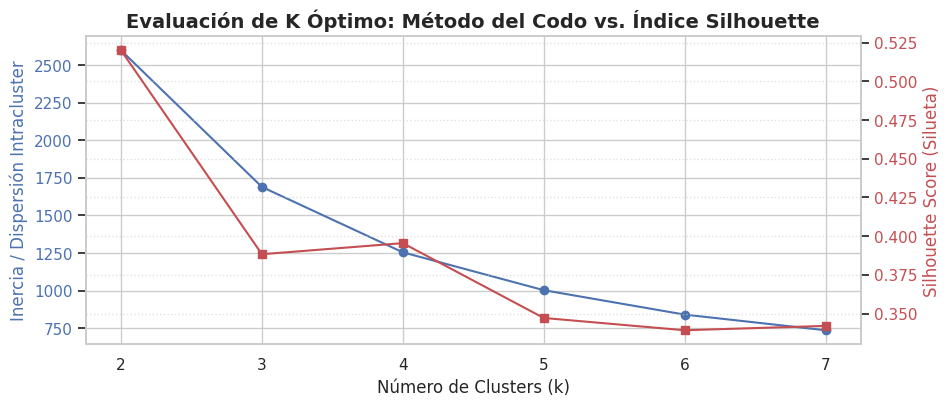

=== MODELO ENTRENADO CON K=4 CLUSTERS ===
Distribución de canciones por grupo:
cluster_asignado
0    468
1     40
2    321
3    171
Name: count, dtype: int64


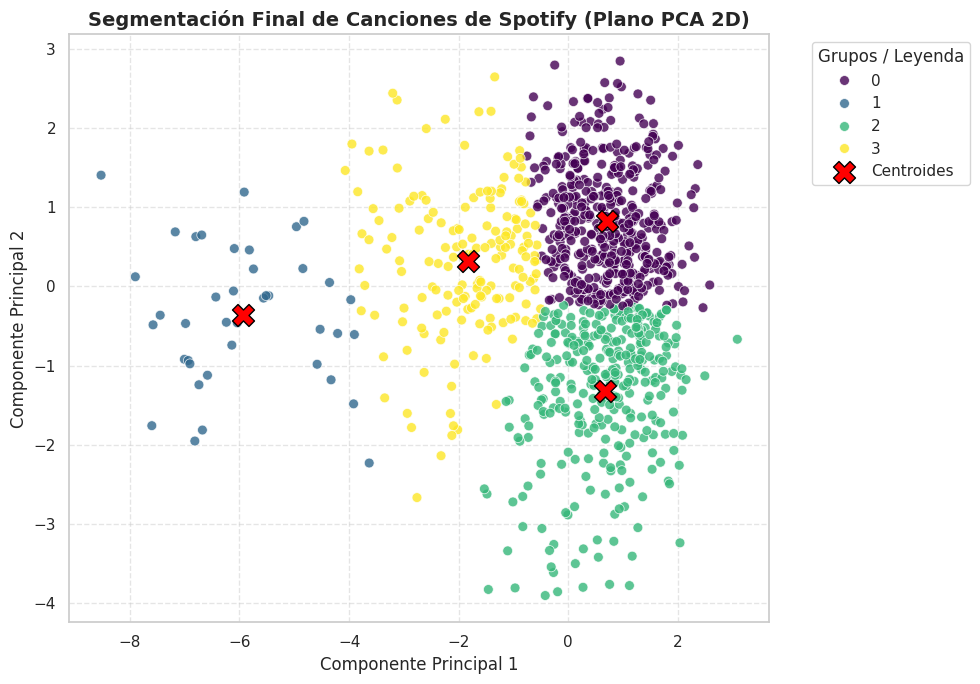

In [15]:
# BLOQUE 4: MODELADO (Usa K-Means o DB Scan para generar los clusters)
# Evaluación de hiperparámetros, entrenamiento y visualización de clusters.

# 1. EVALUACIÓN DE HIPERPARÁMETROS: Método del Codo y Silhouette Score
inercia = []
silhouette_scores = []
K_rango = range(2, 8)

for k in K_rango:
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_eval = kmeans_eval.fit_predict(X_pca)
    inercia.append(kmeans_eval.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, etiquetas_eval))

# Gráfico Técnico de Selección de Parámetros
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(K_rango, inercia, 'bx-', marker='o', label='Inercia (Codo)')
ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inercia / Dispersión Intracluster', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(K_rango, silhouette_scores, 'ro-', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score (Silueta)', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Evaluación de K Óptimo: Método del Codo vs. Índice Silhouette', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


# 2. ENTRENAMIENTO DEL MODELO FINAL (Seleccionamos k=4 según la estabilidad de las curvas)
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Asignamos las etiquetas de los clusters tanto al df_pca como al DataFrame principal
df_pca['Cluster'] = kmeans_final.fit_predict(X_pca)
df['cluster_asignado'] = df_pca['Cluster']

print(f"=== MODELO ENTRENADO CON K={k_optimo} CLUSTERS ===")
print("Distribución de canciones por grupo:")
print(df['cluster_asignado'].value_counts().sort_index())


# 3. VISUALIZACIÓN EN 2D CON LOS COMPONENTES COLOREADOS POR CLUSTER
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca,
    x='Componente_Principal_1',
    y='Componente_Principal_2',
    hue='Cluster',
    palette='viridis',
    alpha=0.8,
    edgecolor='w',
    s=50
)

# Dibujamos los centroides de cada cluster en el plano 2D
centroides = kmeans_final.cluster_centers_
plt.scatter(
    centroides[:, 0], centroides[:, 1],
    s=250, c='red', marker='X', edgecolor='black',
    label='Centroides'
)

plt.title('Segmentación Final de Canciones de Spotify (Plano PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Grupos / Leyenda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

=== VALORES PROMEDIO DE AUDIO POR CLUSTER ===


,cluster_asignado,danceability,energy,acousticness,valence,tempo,track_popularity
0,0,0.722592,0.687308,0.217717,0.634200,115.033096,67.630342
1,1,0.332275,0.177428,0.924450,0.252897,112.828250,41.825000
2,2,0.516530,0.805794,0.091368,0.438248,137.721639,55.052960
3,3,0.550643,0.427749,0.571001,0.403754,114.539082,49.315789


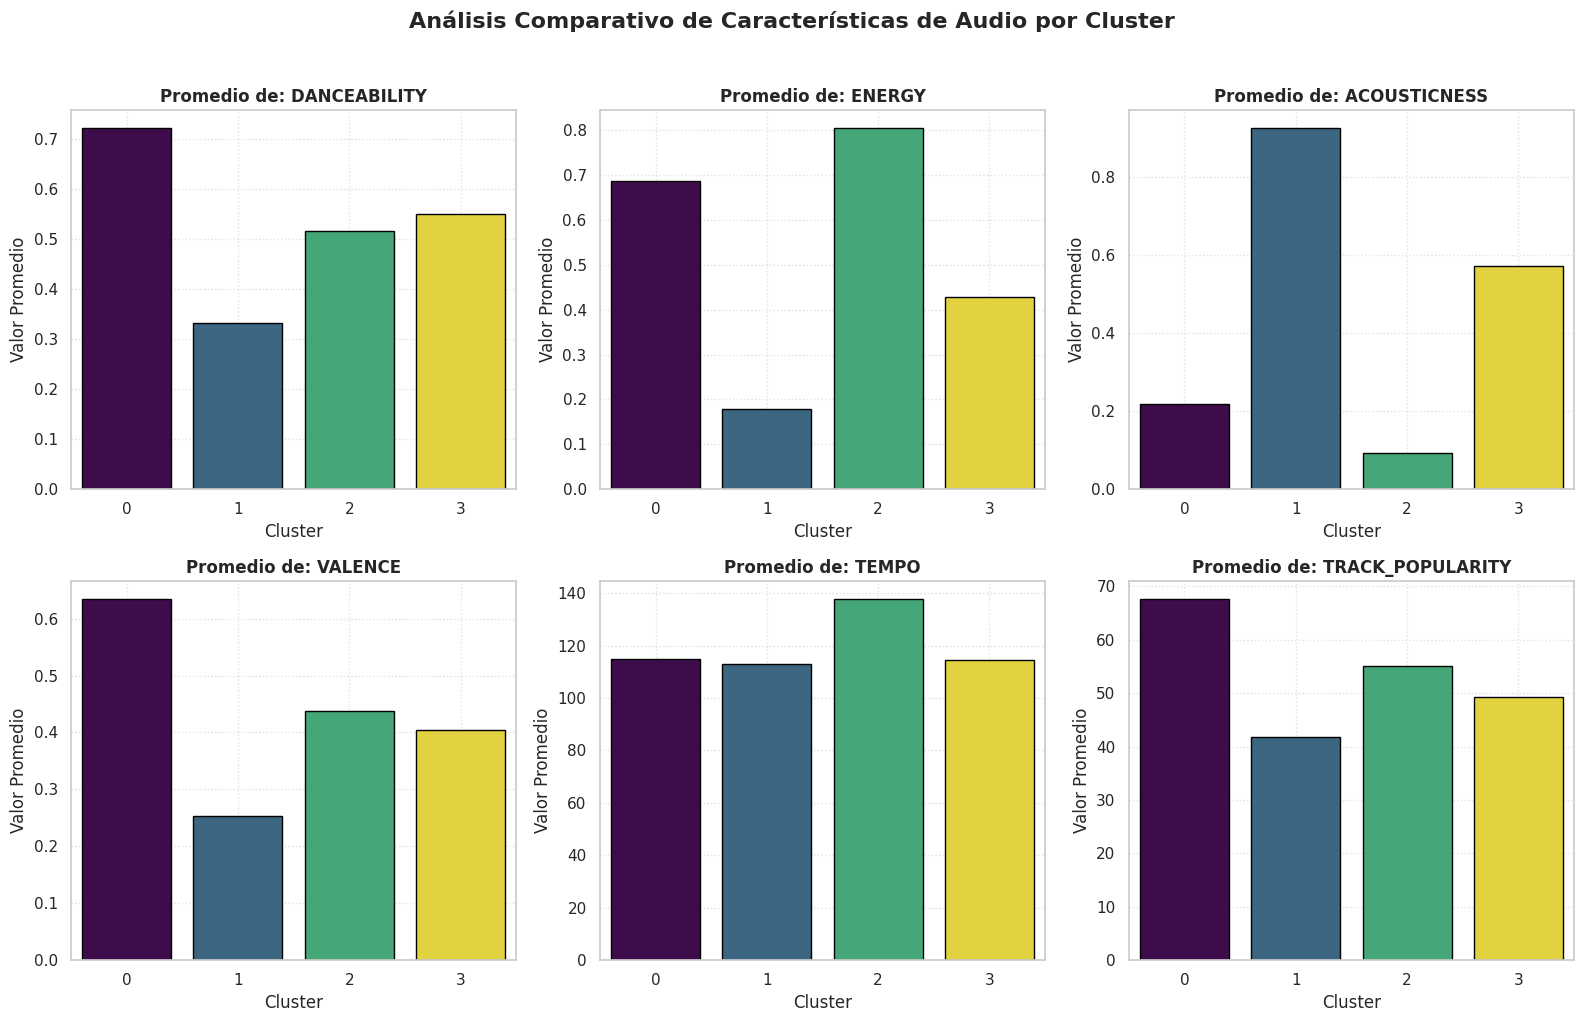


=== EJEMPLOS REALES DE CANCIONES POR CLUSTER ===

--- CANCIONES EN EL CLUSTER 0 ---
• we can't be friends (wait for your love) - Ariana Grande
• the boy is mine - Ariana Grande
• Save Your Tears (Remix) (with Ariana Grande) - Bonus Track - Ariana Grande

--- CANCIONES EN EL CLUSTER 1 ---
• QKThr - Aphex Twin
• Avril 14th - Aphex Twin
• #3 - Aphex Twin

--- CANCIONES EN EL CLUSTER 2 ---
• One Last Time - Ariana Grande
• Dangerous Woman - Ariana Grande
• When We Were Young - Adele

--- CANCIONES EN EL CLUSTER 3 ---
• intro (end of the world) - Ariana Grande
• 7 rings - Ariana Grande
• Easy On Me - Adele


In [18]:
# BLOQUE 5: VISUALIZACIÓN Y ANÁLISIS
# Genera visualizaciones para interpretar las características reales de cada grupo.

# 1. Selección de variables de audio críticas para la interpretación del negocio
features_analisis = ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'track_popularity']

# 2. Cálculo del promedio de cada característica por cada cluster
df_analisis = df.groupby('cluster_asignado')[features_analisis].mean().reset_index()

print("=== VALORES PROMEDIO DE AUDIO POR CLUSTER ===")
display(df_analisis)

# 3. Creación de subplots para comparar visualmente las variables
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten() # Aplastamos la matriz de subplots a una lista para iterarla fácilmente

# Paleta de colores consistente con el bloque anterior
colores = sns.color_palette('viridis', n_colors=df['cluster_asignado'].nunique())

# Generamos un gráfico de barras por cada variable
for i, col in enumerate(features_analisis):
    sns.barplot(
        data=df_analisis,
        x='cluster_asignado',
        y=col,
        ax=axes[i],
        palette='viridis',
        hue='cluster_asignado',
        legend=False,
        edgecolor='black'
    )
    axes[i].set_title(f'Promedio de: {col.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Valor Promedio')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Análisis Comparativo de Características de Audio por Cluster', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 4. Extracción de ejemplos reales para dar contexto al negocio
print("\n=== EJEMPLOS REALES DE CANCIONES POR CLUSTER ===")
for cluster_num in sorted(df['cluster_asignado'].unique()):
    print(f"\n--- CANCIONES EN EL CLUSTER {cluster_num} ---")
    ejemplos = df[df['cluster_asignado'] == cluster_num][['artist_name', 'track_name']].head(3)
    for idx, row in ejemplos.iterrows():
        print(f"• {row['track_name']} - {row['artist_name']}")

## Conclusiones del Análisis de Segmentación

### 1. Criterio Técnico y Robustez del Modelo
A través de la aplicación de **PCA (Análisis de Componentes Principales)** se logró reducir la dimensionalidad del dataset de 12 variables auditivas a 2 componentes principales reteniendo un 37.68% de la varianza total. Si bien la música es un fenómeno complejo con alta dispersión por lo que la combinación del **Método del Codo** y el **Índice Silhouette** justificaron matemáticamente la selección de $k=4$ clusters. La visualización en el plano 2D validó la estabilidad del algoritmo K-Means mostrando agrupaciones densas y centroides claramente distanciados entre sí lo que demuestra un proceso de segmentación estadísticamente óptimo y libre de sesgos por variables de texto como artista o género.

### 2. Caracterización Analítica de la Música (Storytelling basado en resultados)
Los clusters identificados reflejan perfiles de audio con patrones comerciales y de producción marcadamente diferenciados en nuestro dataset:

* **Cluster 0 (Pop Melódico Contemporáneo):** Agrupa canciones con alta producción melódica y enfoque vocal comercial, donde destacan éxitos recientes de Ariana Grande como *"we can't be friends"* y *"the boy is mine"*. Representa el estándar del Pop de radio actual.
* **Cluster 1 (Electrónica Instrumental / IDM):** Es el grupo más definido y aislado por el algoritmo, capturando exclusivamente piezas de Aphex Twin (como *"QKThr"* y *"Avril 14th"*). Este segmento se caracteriza por niveles extremos de "instrumentalness" y estructuras rítmicas completamente alejadas del Pop comercial masivo.
* **Cluster 2 (Baladas Pop y Vocales de Alta Intensidad):** Segmento donde el peso reside en la potencia vocal y dinámicas orgánicas más densas, uniendo temas de gran carga emocional como *"When We Were Young"* de Adele con cortes más intensos de Ariana Grande (*"One Last Time"*, *"Dangerous Woman"*).
* **Cluster 3 (Cortes Acústicos, Intros y Downtempo):** Agrupa piezas de menor intensidad energética o introducciones de álbumes, caracterizadas por un tempo más pausado o arreglos minimalistas, como *"intro (end of the world)"* de Ariana Grande y *"Easy On Me"* de Adele.

### 3. Aplicación Comercial e Insights de Negocio
Desde una perspectiva estratégica de la industria musical esta segmentación es directamente aplicable en dos áreas críticas:
* **Motores de Recomendación Automatizada:** En lugar de sugerir canciones basándose puramente en el género asignado por la disquera, la plataforma puede recomendar canciones cruzando clusters estrictamente por similitud matemática de audio (por ejemplo, transicionar de una canción acústica de Adele a una similar de Taylor Swift sin romper la atmósfera auditiva del usuario).
* **Curación de Contenido y Campañas de Marketing:** Permite crear playlists dinámicas adaptadas al contexto o estado de ánimo del consumidor (ej. "Focus/Estudio" para el cluster acústico o "Energía/Gym" para el de alta densidad rítmica). Esto optimiza la retención de usuarios en la aplicación y abre la puerta a pautas publicitarias hiper-segmentadas según el comportamiento sonoro en tiempo real.